In [8]:
# import libraries

import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from google.cloud import bigquery

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

/home/dd4real2k/code/mlbh/GridZero


In [10]:
import os

print("Current working directory:", os.getcwd())
print("Project root contents:", os.listdir(".."))
print("python_scripts contents:", os.listdir("../python_scripts"))

Current working directory: /home/dd4real2k/code/mlbh/GridZero/notebooks
Project root contents: ['app', 'README.md', 'models', 'status', 'notebooks', 'requirements.txt', 'notes', '.python-version', '.git', 'backend', 'python_scripts', '.gitignore']
python_scripts contents: ['forecastAPI.py', 'random_forest_pipeline.py', 'data_to_bigquery.py', 'Exelon_to_BQ.py', 'xgb_opti.py', '2015_data_pipeline', 'main.py', 'feature_engineering.py', 'loading_and_formatting_data.py', '__init__.py', 'baseline_model.py', 'load_and_merge.py', 'hgb_pipeline.py', '__pycache__', 'lstm_pipeline.py', 'full_data_pipeline', 'python_scripts', 'model_evaluation_xgboost.py']


In [12]:
# Load Dataset from BigQuery

client = bigquery.Client(project="gridzero-489711")

query = """
SELECT *
FROM `gridzero-489711.merged_set.full_feature_engineered_data_test`
ORDER BY datetime
"""

df = client.query(query).to_dataframe()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (148991, 31)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [13]:
# inspect columns

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Columns:
['datetime', 'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'precipitation_mm', 'biomass', 'fossil_gas', 'fossil_hard_coal', 'hydro_pumped_storage', 'hydro_run_of_river_and_poundage', 'nuclear', 'other', 'solar', 'wind_offshore', 'wind_onshore', 'totaloutput_mw', 'carbon_intensity_gco2_kwh', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'carbon_lag_48', 'carbon_lag_336', 'carbon_lag_17520']

Missing values:


carbon_lag_17520                   17699
carbon_lag_336                       515
carbon_lag_48                        227
wind_gusts_10m_ms                      0
datetime                               0
temperature_2m_c                       0
wind_speed_100m_ms                     0
diffuse_radiation_wm2                  0
pressure_msl_hpa                       0
precipitation_mm                       0
biomass                                0
fossil_gas                             0
cloud_cover_pct                        0
shortwave_radiation_wm2                0
direct_radiation_wm2                   0
hydro_run_of_river_and_poundage        0
hydro_pumped_storage                   0
fossil_hard_coal                       0
nuclear                                0
wind_onshore                           0
dtype: int64

## Convert datetime and sort chronologically

Since this is a forecasting problem, we sort the dataset by time.

In [14]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Date range:")
print(df["datetime"].min(), "to", df["datetime"].max())

df[["datetime"]].head()

Date range:
2017-09-12 00:00:00+00:00 to 2026-03-12 23:00:00+00:00


,datetime
0,2017-09-12 00:00:00+00:00
1,2017-09-12 00:30:00+00:00
2,2017-09-12 01:00:00+00:00
3,2017-09-12 01:30:00+00:00
4,2017-09-12 02:00:00+00:00


In [15]:
## Handle missing lag features

lag_features = [
    "carbon_lag_48",
    "carbon_lag_336",
    "carbon_lag_17520"
]

print("Missing before fill:")
print(df[lag_features].isnull().sum())

df[lag_features] = df[lag_features].ffill()

print("\nMissing after fill:")
print(df[lag_features].isnull().sum())

Missing before fill:
carbon_lag_48         227
carbon_lag_336        515
carbon_lag_17520    17699
dtype: int64

Missing after fill:
carbon_lag_48          48
carbon_lag_336        336
carbon_lag_17520    17520
dtype: int64


In [16]:
print("Rows before drop:", len(df))

df = df.dropna(subset=lag_features).reset_index(drop=True)

print("Rows after drop:", len(df))

Rows before drop: 148991
Rows after drop: 131471


In [17]:
print("Final missing values:")
print(df[lag_features].isnull().sum())

Final missing values:
carbon_lag_48       0
carbon_lag_336      0
carbon_lag_17520    0
dtype: int64


In [18]:
# target and features

target = "carbon_intensity_gco2_kwh"

features = [
    "temperature_2m_c",
    "wind_speed_100m_ms",
    "wind_gusts_10m_ms",
    "cloud_cover_pct",
    "shortwave_radiation_wm2",
    "direct_radiation_wm2",
    "diffuse_radiation_wm2",
    "pressure_msl_hpa",
    "precipitation_mm",
    "biomass",
    "fossil_gas",
    "fossil_hard_coal",
    "hydro_pumped_storage",
    "hydro_run_of_river_and_poundage",
    "nuclear",
    "other",
    "solar",
    "wind_offshore",
    "wind_onshore",
    "totaloutput_mw",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "carbon_lag_48",
    "carbon_lag_336",
    "carbon_lag_17520"
]

X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(features))

Feature matrix shape: (131471, 29)
Target shape: (131471,)
Number of features: 29


In [19]:
# Sanity check

print("Any missing values left in features?", X.isnull().sum().sum())
print("Any missing values left in target?", y.isnull().sum())

Any missing values left in features? 0
Any missing values left in target? 0


## Time-based train/test split

We split the data chronologically:
- first 80% for training
- last 20% for testing

This avoids leakage from future data into past data.

In [20]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df[target]
y_test = test_df[target]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (105176, 29) (105176,)
Test shape: (26295, 29) (26295,)


## Train RandomForestRegressor

In [26]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)

print("Random Forest model training completed")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    5.8s


Random Forest model training completed


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   12.4s finished


In [27]:
RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [28]:
RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

## Generate predictions on the test set

In [29]:
predictions = model.predict(X_test)

predictions[:10]

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.4s finished


array([74.34804032, 74.84787629, 73.3196309 , 78.97002893, 79.77238885,
       84.92593499, 85.27987857, 74.13080713, 63.01992539, 69.1682934 ])

## Evaluate model performance

We compute:
- MAE
- RMSE
- R²

In [30]:
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

MAE : 12.6169
RMSE: 16.3717
R2  : 0.9224


## Actual vs Predicted Carbon Intensity

This plot compares the real carbon intensity values with the model predictions over time.

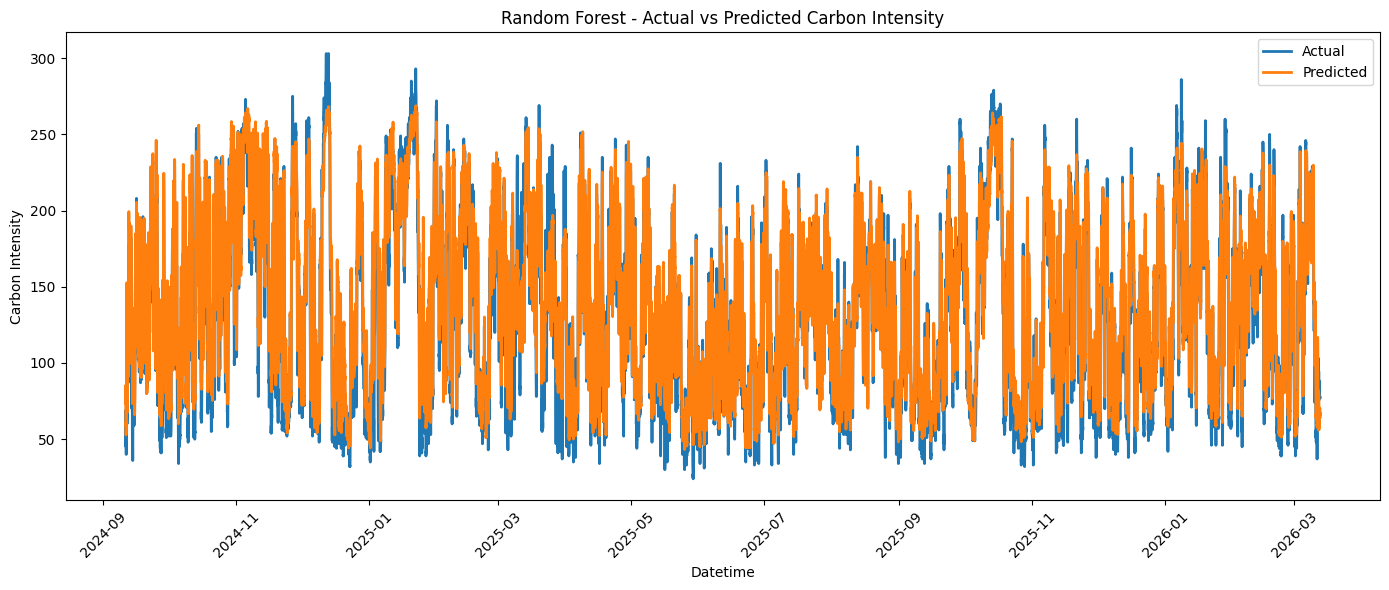

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(test_df["datetime"], y_test, label="Actual", linewidth=2)
plt.plot(test_df["datetime"], predictions, label="Predicted", linewidth=2)

plt.title("Random Forest - Actual vs Predicted Carbon Intensity")
plt.xlabel("Datetime")
plt.ylabel("Carbon Intensity")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Prediction Error Distribution

This histogram shows the distribution of prediction errors.

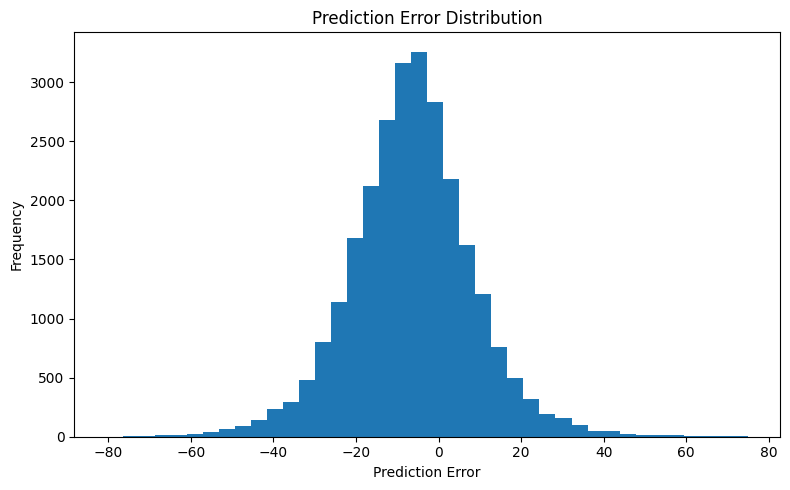

In [32]:
errors = y_test - predictions

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Actual vs Predicted Scatter Plot

A perfect model would produce a straight diagonal line.

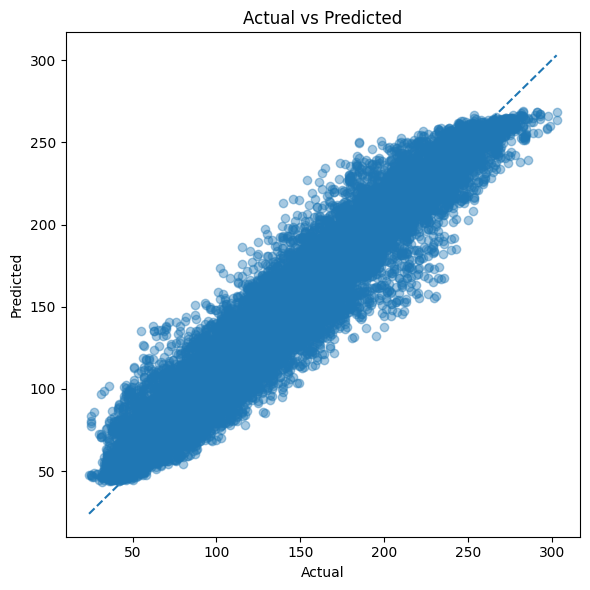

In [33]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, predictions, alpha=0.4)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [34]:
importance = pd.Series(
    model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

importance.head(15)

fossil_gas            0.328048
carbon_lag_48         0.125125
fossil_hard_coal      0.094822
wind_offshore         0.073298
totaloutput_mw        0.068316
wind_onshore          0.065827
wind_speed_100m_ms    0.045569
wind_gusts_10m_ms     0.035018
carbon_lag_336        0.024903
other                 0.018663
biomass               0.012761
doy_cos               0.012090
nuclear               0.011915
carbon_lag_17520      0.010894
temperature_2m_c      0.010112
dtype: float64

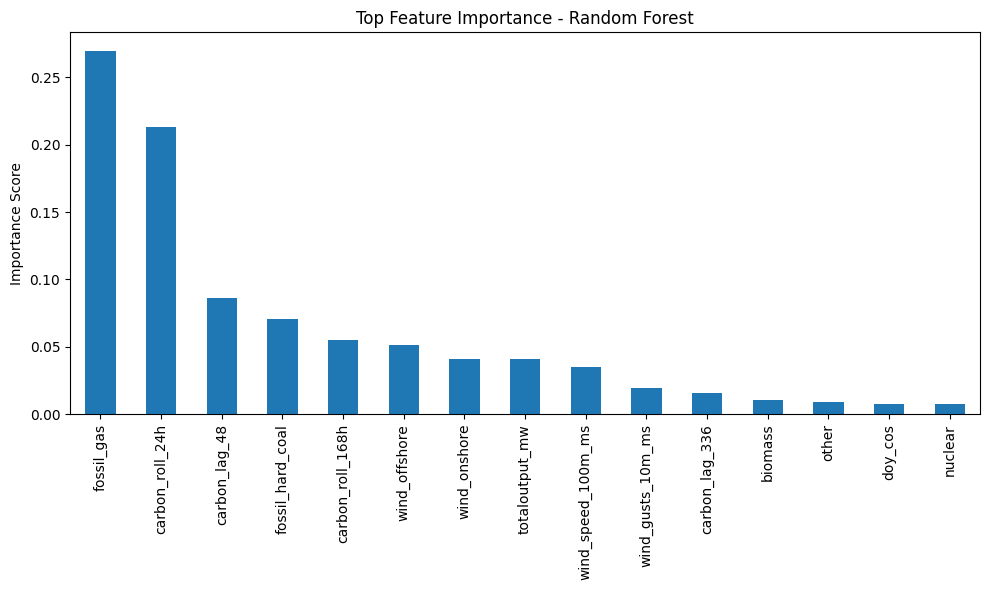

In [ ]:
plt.figure(figsize=(10, 6))

importance.head(15).plot(kind="bar")

plt.title("Top Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [35]:
results = pd.DataFrame({
    "datetime": test_df["datetime"].values,
    "actual": y_test.values,
    "predicted": predictions
})

results.head()

,datetime,actual,predicted
0,2024-09-11 04:00:00,49.0,74.348040
1,2024-09-11 04:30:00,55.0,74.847876
2,2024-09-11 05:00:00,64.0,73.319631
3,2024-09-11 05:30:00,62.0,78.970029
4,2024-09-11 06:00:00,69.0,79.772389


In [36]:
## evaluation summary

summary = pd.DataFrame({
    "model": ["RandomForestRegressor"],
    "target": [target],
    "n_features": [len(features)],
    "train_rows": [len(X_train)],
    "test_rows": [len(X_test)],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

summary

,model,target,n_features,train_rows,test_rows,MAE,RMSE,R2
0,RandomForestRegressor,carbon_intensity_gco2_kwh,29,105176,26295,12.616921,16.371732,0.922415
